# Preprocess the data

In [1]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
from scipy import stats

conn = sqlite3.connect('../slide/database/features.db')
#query = "SELECT channel, COUNT(well) as total_wells FROM LogsChannels GROUP BY channel ORDER BY total_wells DESC"
#df = pd.read_sql_query(query, conn)

In [2]:
query = """
        WITH wells AS (
            SELECT DISTINCT well FROM Features limit 200
        )
        SELECT * FROM Features JOIN wells W USING (well) WHERE Features.rock IS NOT NULL;
    """
df_features = pd.read_sql_query(query, conn)
    
print(f"Fetched {len(df_features)} rows from the database.")
print(f"Total wells fetched: {len(df_features['well'].unique())}")
target_column = 'rock'
features_columns = [
        'depth',
        'top',
        'GR', 
        'SP', 
        'DT', 
        'CALI', 
        'ILD', 
        'RHOB', 
        'NPHI', 
        'MSFL',
        'DRHO', 
        'SFLU']
valid_rocks = [
    'FOLHELHO', 'ARENITO', 'SILTITO', 'CALCILUTITO', 'AREIA', 'CALCARENITO',
    'ARGILA', 'CALCARIO', 'CONGLOMERADO', 'ARGILITO', 'ANIDRITA', 'MARGA',
    'GRANITO', 'BASALTO', 'DOLOMITO'
]

for col in features_columns:
    if col == "GR":
        df_features[col] = np.where((df_features[col] >= 0) & (df_features[col] <= 200), df_features[col], np.nan)
    elif col == "SP":
        df_features[col] = np.where((df_features[col] >= -100) & (df_features[col] <= 100), df_features[col], np.nan)
    elif col == "DT":
        df_features[col] = np.where((df_features[col] >= 40) & (df_features[col] <= 140), df_features[col], np.nan)
    elif col == "CALI":
        df_features[col] = np.where((df_features[col] >= 6) & (df_features[col] <= 16), df_features[col], np.nan)
    elif col == "ILD":
        df_features[col] = np.where((df_features[col] >= 0.2) & (df_features[col] <= 2000), df_features[col], np.nan)
    elif col == "RHOB":
        df_features[col] = np.where((df_features[col] >= 1.95) & (df_features[col] <= 2.95), df_features[col], np.nan)
    elif col == "NPHI":
        df_features[col] = np.where((df_features[col] >= 0) & (df_features[col] <= 0.45), df_features[col], np.nan)
    elif col == "MSFL":
        df_features[col] = np.where((df_features[col] >= 0.2) & (df_features[col] <= 2000), df_features[col], np.nan)
    elif col == "DRHO":
        df_features[col] = np.where((df_features[col] >= -0.1) & (df_features[col] <= 0.3), df_features[col], np.nan)
    elif col == "SFLU":
        df_features[col] = np.where((df_features[col] >= 0.2) & (df_features[col] <= 2000), df_features[col], np.nan)

# Filter rows based on valid rock types
df_features["rock"] = np.where(df_features['rock'].isin(valid_rocks), df_features["rock"], np.nan)

Fetched 2457094 rows from the database.
Total wells fetched: 199


In [3]:
# Add boolean columns indicating null values for each numeric column
for col in features_columns:
    df_features[f'{col}_is_null'] = df_features[col].isnull().astype(int)
    
feature_cols = features_columns + [f'{col}_is_null' for col in features_columns]

In [4]:
def _add_sequential_features(df: pd.DataFrame, features_columns: list) -> pd.DataFrame:
    """Add lagged features to capture sequential dependencies"""
    df = df.sort_values(['well', 'depth'])  # Ensure sorted by well and depth
    
    # Add lagged features (previous depth values)
    for col in features_columns:
        # Previous value (lag 1)
        df[f'{col}_lag1'] = df.groupby('well')[col].shift(1)
        # Previous 2 values (lag 2)
        df[f'{col}_lag2'] = df.groupby('well')[col].shift(2)
        
        # Rolling statistics (window of 3)
        df[f'{col}_rolling_mean'] = df.groupby('well')[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).mean()
        )
        df[f'{col}_rolling_std'] = df.groupby('well')[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).std()
        )
        
        # Rate of change
        df[f'{col}_diff'] = df.groupby('well')[col].diff()
    
    return df

print("Completed data cleaning and preprocessing steps.")
print(f"Dataframe shape after cleaning: {df_features.shape}")
print(f"Dataframe sample after cleaning: {df_features.head()}")

# Add sequential features BEFORE splitting
df_features = _add_sequential_features(df_features, features_columns)

# Include sequential features
sequential_features = []
for col in features_columns:
    sequential_features.extend([
        f'{col}_lag1', f'{col}_lag2', 
        f'{col}_rolling_mean', f'{col}_rolling_std',
        f'{col}_diff'
    ])
    
feature_cols = features_columns + [f'{col}_is_null' for col in features_columns] + sequential_features

Completed data cleaning and preprocessing steps.
Dataframe shape after cleaning: (2457094, 27)
Dataframe sample after cleaning:      well  depth         GR         SP  DT  CALI         ILD  RHOB  NPHI  \
0  1AA1RN   15.0  29.094528  14.132740 NaN   NaN   71.176651   NaN   NaN   
1  1AA1RN   15.2  25.903702  14.019028 NaN   NaN   79.702988   NaN   NaN   
2  1AA1RN   15.4  24.299988        NaN NaN   NaN         NaN   NaN   NaN   
3  1AA1RN   15.4  24.299988  37.723557 NaN   NaN  107.772736   NaN   NaN   
4  1AA1RN   15.6  24.444855  15.843269 NaN   NaN   97.067352   NaN   NaN   

   MSFL  ...  GR_is_null  SP_is_null  DT_is_null  CALI_is_null ILD_is_null  \
0   NaN  ...           0           0           1             1           0   
1   NaN  ...           0           0           1             1           0   
2   NaN  ...           0           1           1             1           1   
3   NaN  ...           0           0           1             1           0   
4   NaN  ...           0 

In [5]:
# Get unique wells
from sklearn.model_selection import train_test_split

unique_wells = df_features['well'].unique()

# Split wells into train and test (80-20 split)
train_wells, test_wells = train_test_split(unique_wells, test_size=0.2, random_state=42)

# Create train and test datasets based on well splits
train_data = df_features[df_features['well'].isin(train_wells)]
test_data = df_features[df_features['well'].isin(test_wells)]

train_target = train_data[target_column]
test_target = test_data[target_column]

train_data = train_data[feature_cols]
test_data = test_data[feature_cols]

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Create masks for training and testing data
train_mask = train_target.notna()
test_mask = test_target.notna()

train_data = train_data[train_mask]
train_target = train_target[train_mask]
test_data = test_data[test_mask]
test_target = test_target[test_mask]

# Handle missing values by imputing with median for numeric features
imputer = SimpleImputer(strategy='median')
train_data_imputed = imputer.fit_transform(train_data)
test_data_imputed = imputer.transform(test_data)

def evaluate_model(train_predictions, test_predictions, X_train, y_train, x_test, y_test):
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    
    print("Classification Report on Test Data:")
    print(classification_report(y_test, test_predictions))

In [7]:
def train_rf(train_data, train_target, test_data, test_target):

    # Train Random Forest classifier
    rf_model = RandomForestClassifier(
        n_estimators=100,
        n_jobs=20,
        random_state=42,
        verbose=1,  # This will show progress during training
        warm_start=True,  # Allow incremental training to track progress
        bootstrap=False  # Disable bootstrap to avoid breaking the sequential nature of well logs
    )

    # Train the model
    print("Training Random Forest model...")
    rf_model.fit(train_data, train_target)

    # Make predictions
    train_predictions = rf_model.predict(train_data)
    test_predictions = rf_model.predict(test_data)
        
    evaluate_model(train_predictions, test_predictions, train_data, train_target, test_data, test_target)

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))

In [8]:
from sklearn.neighbors import KNeighborsClassifier

def train_knn(train_data, train_target, test_data, test_target):

    # Train KNN classifier
    knn_model = KNeighborsClassifier(
        n_neighbors=5, 
        n_jobs=20,
        verbose=1,
        metric='euclidean'
        )

    # Train the model
    print("Training KNN model...")
    knn_model.fit(train_data, train_target)

    # Make predictions
    train_predictions = knn_model.predict(train_data)
    test_predictions = knn_model.predict(test_data)
        
    evaluate_model(train_predictions, test_predictions, train_data, train_target, test_data, test_target)

In [9]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
def train_xgboost(train_data, train_target, test_data, test_target):
    
    # Encode target labels (XGBoost requires numeric labels)
    label_encoder = LabelEncoder()
    train_target_encoded = label_encoder.fit_transform(train_target)
    test_target_encoded = label_encoder.transform(test_target)

    # Train XGBoost classifier
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        n_jobs=20,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        learning_rate=0.001,
        verbose=1
    )

    # Train the model
    print("Training XGBoost model...")
    xgb_model.fit(train_data, train_target_encoded)

    # Make predictions
    train_predictions = xgb_model.predict(train_data)
    test_predictions = xgb_model.predict(test_data)
        
    evaluate_model(train_predictions, test_predictions, train_data, train_target_encoded, test_data, test_target_encoded)

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
SEQUENCE_LENGTH = 10  # Use 10 consecutive depth readings
NUM_EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============ Define LSTM Model ============
class LSTMClassifier(nn.Module):
    def __init__(self, num_features, hidden_size=128, num_layers=2, num_classes=15, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, num_features)
        lstm_out, (hidden, cell) = self.lstm(x)
        # Use last hidden state
        out = self.fc(hidden[-1])  # (batch_size, num_classes)
        return out

def create_sequences(data, targets, sequence_length=10):
    """
    Create sequences from well log data.
    Each sequence = sequence_length consecutive readings.
    Target = the rock type at the end of each sequence.
    """
    sequences = []
    target_labels = []
    
    for idx in range(len(data) - sequence_length):
        sequences.append(data[idx:idx + sequence_length])
        target_labels.append(targets.iloc[idx + sequence_length])
    
    return np.array(sequences), np.array(target_labels)


# ============ Prepare data ============
# Impute missing values (LSTM needs complete sequences)
def train_lstm(train_data, train_target, test_data, test_target):
    
    # Create sequences
    train_sequences, train_targets_seq = create_sequences(
        train_data, 
        train_target, 
        SEQUENCE_LENGTH
    )
    test_sequences, test_targets_seq = create_sequences(
        test_data, 
        test_target, 
        SEQUENCE_LENGTH
    )

    print(f"Train sequences shape: {train_sequences.shape}")
    print(f"Test sequences shape: {test_sequences.shape}")
    print(f"Train targets shape: {train_targets_seq.shape}")

    # Encode targets
    label_encoder_lstm = LabelEncoder()
    train_targets_encoded = label_encoder_lstm.fit_transform(train_targets_seq)
    test_targets_encoded = label_encoder_lstm.transform(test_targets_seq)
    
    num_classes = len(label_encoder_lstm.classes_)
    num_features = train_sequences.shape[2]

    print(f"Num classes: {num_classes}, Num features: {num_features}")

    # Convert to PyTorch tensors (keep on CPU, DataLoader will batch them)
    train_sequences_tensor = torch.FloatTensor(train_sequences)  # Don't move to GPU yet
    train_targets_tensor = torch.LongTensor(train_targets_encoded)
    test_sequences_tensor = torch.FloatTensor(test_sequences)
    test_targets_tensor = torch.LongTensor(test_targets_encoded)

    # Create DataLoaders (pin_memory helps CPU→GPU transfer)
    train_dataset = TensorDataset(train_sequences_tensor, train_targets_tensor)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, pin_memory=True)  # Reduced from 64

    test_dataset = TensorDataset(test_sequences_tensor, test_targets_tensor)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, pin_memory=True)
    
    # ============ Train LSTM ============
    model = LSTMClassifier(
        num_features=num_features,
        hidden_size=128,
        num_layers=2,
        num_classes=num_classes,
        dropout=0.3
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(NUM_EPOCHS):
        # ---- Train ----
        model.train()
        train_loss = 0
        train_preds_epoch = []
        train_true_epoch = []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)  # Move only batch to GPU
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
            train_preds_epoch.append(logits.argmax(dim=1).detach().cpu().numpy())
            train_true_epoch.append(batch_y.detach().cpu().numpy())
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Train accuracy (computed from batches)
        train_preds_all = np.concatenate(train_preds_epoch)
        train_true_all = np.concatenate(train_true_epoch)
        train_acc = accuracy_score(train_true_all, train_preds_all)
        train_accs.append(train_acc)
        
        # ---- Evaluate on Test ----
        model.eval()
        test_preds_epoch = []
        test_true_epoch = []
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
                logits = model(batch_x)
                test_preds_epoch.append(logits.argmax(dim=1).detach().cpu().numpy())
                test_true_epoch.append(batch_y.detach().cpu().numpy())
        
        test_preds_all = np.concatenate(test_preds_epoch)
        test_true_all = np.concatenate(test_true_epoch)
        test_acc = accuracy_score(test_true_all, test_preds_all)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    print(f"\n{'='*60}")
    print("LSTM Training Complete")
    print(f"{'='*60}")
    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Test Accuracy: {test_acc:.4f}")
    print(f"Overfitting Gap: {train_acc - test_acc:.4f}")

    # ============ Final Evaluation ============
    model.eval()
    test_preds_final = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE)
            logits = model(batch_x)
            test_preds_final.append(logits.argmax(dim=1).detach().cpu().numpy())
    
    test_preds_final = np.concatenate(test_preds_final)
    test_preds_decoded = label_encoder_lstm.inverse_transform(test_preds_final)
    test_targets_decoded = label_encoder_lstm.inverse_transform(test_true_all)

    print("\nClassification Report (Test Set):")
    print(classification_report(test_targets_decoded, test_preds_decoded))

    # Plot training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('LSTM Training Loss')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc', alpha=0.7)
    plt.plot(test_accs, label='Test Acc', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('LSTM Train vs Test Accuracy')
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(test_targets_decoded, test_preds_decoded, 
                        labels=label_encoder_lstm.classes_)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder_lstm.classes_,
                yticklabels=label_encoder_lstm.classes_)
    plt.title('LSTM Confusion Matrix (Test Set)', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [22]:
from sklearn.tree import DecisionTreeClassifier


def train_dt(train_data, train_target, test_data, test_target):

    # Train Decision Tree classifier
    dt_model = DecisionTreeClassifier(
        random_state=42,
        min_samples_split=4,
        min_samples_leaf=2
    )

    # Train the model
    print("Training Decision Tree model...")
    dt_model.fit(train_data, train_target)

    # Make predictions
    train_predictions = dt_model.predict(train_data)
    test_predictions = dt_model.predict(test_data)
        
    evaluate_model(train_predictions, test_predictions, train_data, train_target, test_data, test_target)

In [23]:

from sklearn.linear_model import LogisticRegression


def train_logistic(train_data, train_target, test_data, test_target):

    # Train Logistic Regression classifier
    logistic_model = LogisticRegression(
        max_iter=200,
        C=1.0,
        random_state=42,
        verbose=1,
        n_jobs=20
    )

    # Train the model
    print("Training Logistic Regression model...")
    logistic_model.fit(train_data, train_target)

    # Make predictions
    train_predictions = logistic_model.predict(train_data)
    test_predictions = logistic_model.predict(test_data)
        
    evaluate_model(train_predictions, test_predictions, train_data, train_target, test_data, test_target)

In [24]:
print("\n" + "="*50 + "\n")
print("Training Decision Tree without imputed data")
train_dt(train_data, train_target, test_data, test_target)
print("Training Decision Tree with imputed data")
train_dt(train_data_imputed, train_target, test_data_imputed, test_target)
print("\n" + "="*50 + "\n")



Training Decision Tree without imputed data
Training Decision Tree model...
Training Accuracy: 0.9761
Testing Accuracy: 0.3147
Classification Report on Test Data:


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

              precision    recall  f1-score   support

    ANIDRITA       0.04      0.39      0.08      3081
       AREIA       0.04      0.51      0.07       550
     ARENITO       0.44      0.35      0.39    237810
      ARGILA       0.01      0.04      0.02      1368
    ARGILITO       0.15      0.26      0.19     12893
     BASALTO       0.00      0.00      0.00      9464
 CALCARENITO       0.18      0.28      0.22     21639
    CALCARIO       0.09      0.09      0.09      5908
 CALCILUTITO       0.05      0.13      0.07     11857
CONGLOMERADO       0.05      0.03      0.04     29218
    DOLOMITO       0.00      0.00      0.00       387
    FOLHELHO       0.41      0.45      0.43    203028
     GRANITO       0.00      0.00      0.00        39
       MARGA       0.00      0.00      0.00       262
     SILTITO       0.13      0.08      0.10     80436

    accuracy                           0.31    617940
   macro avg       0.11      0.17      0.11    617940
weighted avg       0.33   

In [26]:
print("\n" + "="*50 + "\n")
#print("Training Logistic Regression without imputed data")
#train_logistic(train_data, train_target, test_data, test_target)
print("Training Logistic Regression with imputed data")
train_logistic(train_data_imputed, train_target, test_data_imputed, test_target)
print("\n" + "="*50 + "\n")



Training Logistic Regression with imputed data
Training Logistic Regression model...


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=20', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy: 0.4655
Testing Accuracy: 0.3644
Classification Report on Test Data:


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    ANIDRITA       0.03      0.24      0.05      3081
       AREIA       0.03      0.27      0.05       550
     ARENITO       0.42      0.16      0.24    237810
      ARGILA       0.00      0.00      0.00      1368
    ARGILITO       0.30      0.05      0.09     12893
     BASALTO       0.00      0.00      0.00      9464
 CALCARENITO       0.03      0.00      0.01     21639
    CALCARIO       0.00      0.00      0.00      5908
 CALCILUTITO       0.00      0.00      0.00     11857
CONGLOMERADO       0.59      0.42      0.49     29218
    DOLOMITO       0.00      0.00      0.00       387
    FOLHELHO       0.37      0.85      0.51    203028
     GRANITO       0.00      0.00      0.00        39
       MARGA       0.00      0.00      0.00       262
     SILTITO       0.00      0.00      0.00     80436

    accuracy                           0.36    617940
   macro avg       0.12      0.13      0.10    617940
weighted avg       0.32   

d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [51]:
print("\n" + "="*50 + "\n")
#print("Training LSTM without imputed data")
#train_lstm(train_data, train_target, test_data, test_target)
print("Training LSTM with imputed data")
train_lstm(train_data_imputed, train_target, test_data_imputed, test_target)
print("\n" + "="*50 + "\n")



Training LSTM with imputed data
Train sequences shape: (1671065, 10, 24)
Test sequences shape: (617930, 10, 24)
Train targets shape: (1671065,)
Num classes: 15, Num features: 24
Epoch 5/30 | Loss: 1.1458 | Train Acc: 0.5943 | Test Acc: 0.4358
Epoch 10/30 | Loss: 1.1120 | Train Acc: 0.6069 | Test Acc: 0.4850
Epoch 15/30 | Loss: 1.1310 | Train Acc: 0.6033 | Test Acc: 0.4545


KeyboardInterrupt: 

In [23]:
print("\n" + "="*50 + "\n")
print("Training RF without imputed data")
train_rf(train_data, train_target, test_data, test_target)
print("Training RF with imputed data")
train_rf(train_data_imputed, train_target, test_data_imputed, test_target)
print("\n" + "="*50 + "\n")



Training RF without imputed data
Training Random Forest model...


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:   50.1s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:  4.8min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    1.9s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:   11.2s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    3.9s finished


Training Accuracy: 0.9992
Testing Accuracy: 0.4319
Classification Report on Test Data:


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

              precision    recall  f1-score   support

    ANIDRITA       0.12      0.46      0.19      3081
       AREIA       0.03      0.34      0.05       550
     ARENITO       0.54      0.49      0.51    237810
      ARGILA       0.02      0.03      0.03      1368
    ARGILITO       0.26      0.31      0.28     12893
     BASALTO       0.00      0.00      0.00      9464
 CALCARENITO       0.38      0.32      0.35     21639
    CALCARIO       0.13      0.03      0.05      5908
 CALCILUTITO       0.16      0.06      0.08     11857
CONGLOMERADO       0.10      0.06      0.07     29218
    DOLOMITO       0.00      0.00      0.00       387
    FOLHELHO       0.43      0.67      0.52    203028
     GRANITO       0.00      0.00      0.00        39
       MARGA       0.00      0.00      0.00       262
     SILTITO       0.11      0.01      0.03     80436

    accuracy                           0.43    617940
   macro avg       0.15      0.18      0.14    617940
weighted avg       0.39   

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:  1.1min
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:  4.5min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    1.8s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:   10.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    3.5s finished


Training Accuracy: 0.9992
Testing Accuracy: 0.4151
Classification Report on Test Data:


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

              precision    recall  f1-score   support

    ANIDRITA       0.13      0.47      0.20      3081
       AREIA       0.03      0.37      0.05       550
     ARENITO       0.51      0.43      0.47    237810
      ARGILA       0.02      0.04      0.03      1368
    ARGILITO       0.27      0.30      0.29     12893
     BASALTO       0.00      0.00      0.00      9464
 CALCARENITO       0.42      0.32      0.36     21639
    CALCARIO       0.13      0.03      0.05      5908
 CALCILUTITO       0.19      0.08      0.11     11857
CONGLOMERADO       0.31      0.11      0.16     29218
    DOLOMITO       0.00      0.00      0.00       387
    FOLHELHO       0.40      0.67      0.50    203028
     GRANITO       0.00      0.00      0.00        39
       MARGA       0.00      0.00      0.00       262
     SILTITO       0.11      0.01      0.02     80436

    accuracy                           0.42    617940
   macro avg       0.17      0.19      0.15    617940
weighted avg       0.38   

In [25]:
print("\n" + "="*50 + "\n")
#print("Training KNN without imputed data")
#train_knn(train_data, train_target, test_data, test_target)
print("Training KNN with imputed data")
train_knn(train_data_imputed, train_target, test_data_imputed, test_target)
print("\n" + "="*50 + "\n")



Training KNN with imputed data
Training KNN model...
Training Accuracy: 0.9292
Testing Accuracy: 0.3326
Classification Report on Test Data:


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    ANIDRITA       0.07      0.23      0.11      3081
       AREIA       0.02      0.27      0.03       550
     ARENITO       0.45      0.39      0.42    237810
      ARGILA       0.01      0.02      0.01      1368
    ARGILITO       0.14      0.19      0.16     12893
     BASALTO       0.00      0.00      0.00      9464
 CALCARENITO       0.20      0.18      0.19     21639
    CALCARIO       0.06      0.05      0.06      5908
 CALCILUTITO       0.05      0.09      0.06     11857
CONGLOMERADO       0.22      0.18      0.19     29218
    DOLOMITO       0.00      0.00      0.00       387
    FOLHELHO       0.42      0.45      0.43    203028
     GRANITO       0.00      0.00      0.00        39
       MARGA       0.00      0.00      0.00       262
     SILTITO       0.10      0.11      0.10     80436

    accuracy                           0.33    617940
   macro avg       0.11      0.14      0.12    617940
weighted avg       0.34   

d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [39]:
print("\n" + "="*50 + "\n")
print("Training XGBoost without imputed data")
train_xgboost(train_data, train_target, test_data, test_target)
print("Training XGBoost with imputed data")
train_xgboost(train_data_imputed, train_target, test_data_imputed, test_target)
print("\n" + "="*50 + "\n")



Training XGBoost without imputed data
Training XGBoost model...


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:11:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Accuracy: 0.6270
Testing Accuracy: 0.5075
Classification Report on Test Data:


d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

              precision    recall  f1-score   support

           0       0.28      0.39      0.33      3081
           1       0.05      0.37      0.09       550
           2       0.61      0.57      0.59    237810
           3       0.00      0.00      0.00      1368
           4       0.33      0.22      0.26     12893
           5       0.00      0.00      0.00      9464
           6       0.41      0.14      0.21     21639
           7       0.00      0.00      0.00      5908
           8       0.31      0.04      0.07     11857
           9       0.56      0.38      0.45     29218
          10       0.00      0.00      0.00       387
          11       0.47      0.79      0.59    203028
          12       0.00      0.00      0.00        39
          13       0.00      0.00      0.00       262
          14       0.04      0.00      0.00     80436

    accuracy                           0.51    617940
   macro avg       0.20      0.19      0.17    617940
weighted avg       0.45   

d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:13:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Accuracy: 0.6201
Testing Accuracy: 0.4742
Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.27      0.38      0.31      3081
           1       0.04      0.18      0.06       550
           2       0.56      0.46      0.51    237810
           3       0.00      0.00      0.00      1368
           4       0.32      0.23      0.27     12893
           5       0.00      0.00      0.00      9464
           6       0.44      0.14      0.21     21639
           7       0.00      0.00      0.00      5908
           8       0.35      0.04      0.07     11857
           9       0.66      0.39      0.49     29218
          10       0.00      0.00      0.00       387
          11       0.44      0.80      0.56    203028
          12       0.00      0.00      0.00        39
          13       0.00      0.00      0.00       262
          14       0.30      0.00      0.00     80436

    accuracy                           0.47    

d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\GeoAI-ANP-DataExtractor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [54]:
target_column = 'rock'
features_columns = [
        'depth',
        'top',
        'GR', 
        'SP', 
        'DT', 
        'CALI', 
        'ILD', 
        'RHOB', 
        'NPHI', 
        'MSFL',
        'DRHO', 
        'SFLU']
valid_rocks = [
    'FOLHELHO', 'ARENITO', 'SILTITO', 'CALCILUTITO', 'AREIA', 'CALCARENITO',
    'ARGILA', 'CALCARIO', 'CONGLOMERADO', 'ARGILITO', 'ANIDRITA', 'MARGA',
    'GRANITO', 'BASALTO', 'DOLOMITO'
]
"""
0        FOLHELHO  323879       42.41
1         ARENITO  278184       36.43
2         SILTITO   62312        8.16
3        ARGILITO   30446        3.99
4     CALCILUTITO   28771        3.77
5           AREIA    8235        1.08
6     CALCARENITO    6894        0.90
7          ARGILA    5886        0.77
8        CALCARIO    5091        0.67
9    CONGLOMERADO    4934        0.65
10        GRANITO    2797        0.37
11         HALITA    2484        0.33
12       ANIDRITA    1433        0.19
13       DOLOMITO    1083        0.14
14        BASALTO     776        0.10

0         ARENITO           63            100.00
1        FOLHELHO           63            100.00
2         SILTITO           60             95.24
3     CALCILUTITO           58             92.06
4           AREIA           34             53.97
5     CALCARENITO           32             50.79
6          ARGILA           29             46.03
7        CALCARIO           10             15.87
8    CONGLOMERADO            9             14.29
9        ARGILITO            8             12.70
10       ANIDRITA            8             12.70
11          MARGA            6              9.52
12        GRANITO            3              4.76
13        BASALTO            3              4.76
14       DOLOMITO            3              4.76
"""

'\n0        FOLHELHO  323879       42.41\n1         ARENITO  278184       36.43\n2         SILTITO   62312        8.16\n3        ARGILITO   30446        3.99\n4     CALCILUTITO   28771        3.77\n5           AREIA    8235        1.08\n6     CALCARENITO    6894        0.90\n7          ARGILA    5886        0.77\n8        CALCARIO    5091        0.67\n9    CONGLOMERADO    4934        0.65\n10        GRANITO    2797        0.37\n11         HALITA    2484        0.33\n12       ANIDRITA    1433        0.19\n13       DOLOMITO    1083        0.14\n14        BASALTO     776        0.10\n\n0         ARENITO           63            100.00\n1        FOLHELHO           63            100.00\n2         SILTITO           60             95.24\n3     CALCILUTITO           58             92.06\n4           AREIA           34             53.97\n5     CALCARENITO           32             50.79\n6          ARGILA           29             46.03\n7        CALCARIO           10             15.87\n8    CONGL

In [55]:


df_features_filtered = df_features.copy()

# Replace outliers with NaN
for col in features_columns:
    if col == "GR":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0) & (df_features_filtered[col] <= 200), df_features_filtered[col], np.nan)
    elif col == "SP":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= -100) & (df_features_filtered[col] <= 100), df_features_filtered[col], np.nan)
    elif col == "DT":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 40) & (df_features_filtered[col] <= 140), df_features_filtered[col], np.nan)
    elif col == "CALI":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 6) & (df_features_filtered[col] <= 16), df_features_filtered[col], np.nan)
    elif col == "ILD":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0.2) & (df_features_filtered[col] <= 2000), df_features_filtered[col], np.nan)
    elif col == "RHOB":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 1.95) & (df_features_filtered[col] <= 2.95), df_features_filtered[col], np.nan)
    elif col == "NPHI":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0) & (df_features_filtered[col] <= 0.45), df_features_filtered[col], np.nan)
    elif col == "MSFL":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0.2) & (df_features_filtered[col] <= 2000), df_features_filtered[col], np.nan)
    elif col == "DRHO":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= -0.1) & (df_features_filtered[col] <= 0.3), df_features_filtered[col], np.nan)
    elif col == "SFLU":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0.2) & (df_features_filtered[col] <= 2000), df_features_filtered[col], np.nan)

# Filter rows based on valid rock types
df_features_filtered["rock"] = np.where(df_features_filtered['rock'].isin(valid_rocks), df_features_filtered["rock"], np.nan)
df_features_filtered.describe()


,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom
count,1000000.000000,663835.000000,559598.000000,274282.000000,405858.000000,484782.000000,359782.000000,694.000000,20697.000000,360807.000000,211845.000000,763708.000000,763708.000000
mean,2628.180389,68.657219,-29.796024,79.454698,10.570919,16.715606,2.450975,0.226148,6.624779,0.063885,58.187587,1424.764031,1438.812599
std,2499.114037,36.952135,22.406872,17.256518,1.900508,94.249221,0.147991,0.130741,34.920636,0.066575,262.547742,904.390223,907.683394
min,0.400000,0.000000,-99.997986,40.000000,6.077258,0.201597,1.950054,0.000000,0.225098,-0.099896,0.229858,3.000000,12.000000
25%,902.000000,44.714020,-45.144196,67.255821,8.935061,3.405273,2.355713,0.118920,0.784668,0.014000,4.698598,718.000000,729.000000
50%,1704.400000,69.781998,-28.670006,75.733414,9.943123,6.002999,2.461975,0.220288,1.957779,0.041000,7.894531,1305.000000,1313.000000
75%,3412.000000,92.366989,-13.561481,88.242188,12.142834,10.679688,2.564814,0.340750,6.351562,0.092350,15.377369,1997.000000,2007.000000
max,15427.657480,200.000000,64.203094,140.000000,16.000000,2000.000000,2.949828,0.449642,1956.429443,0.300000,2000.000000,4731.000000,5049.500000


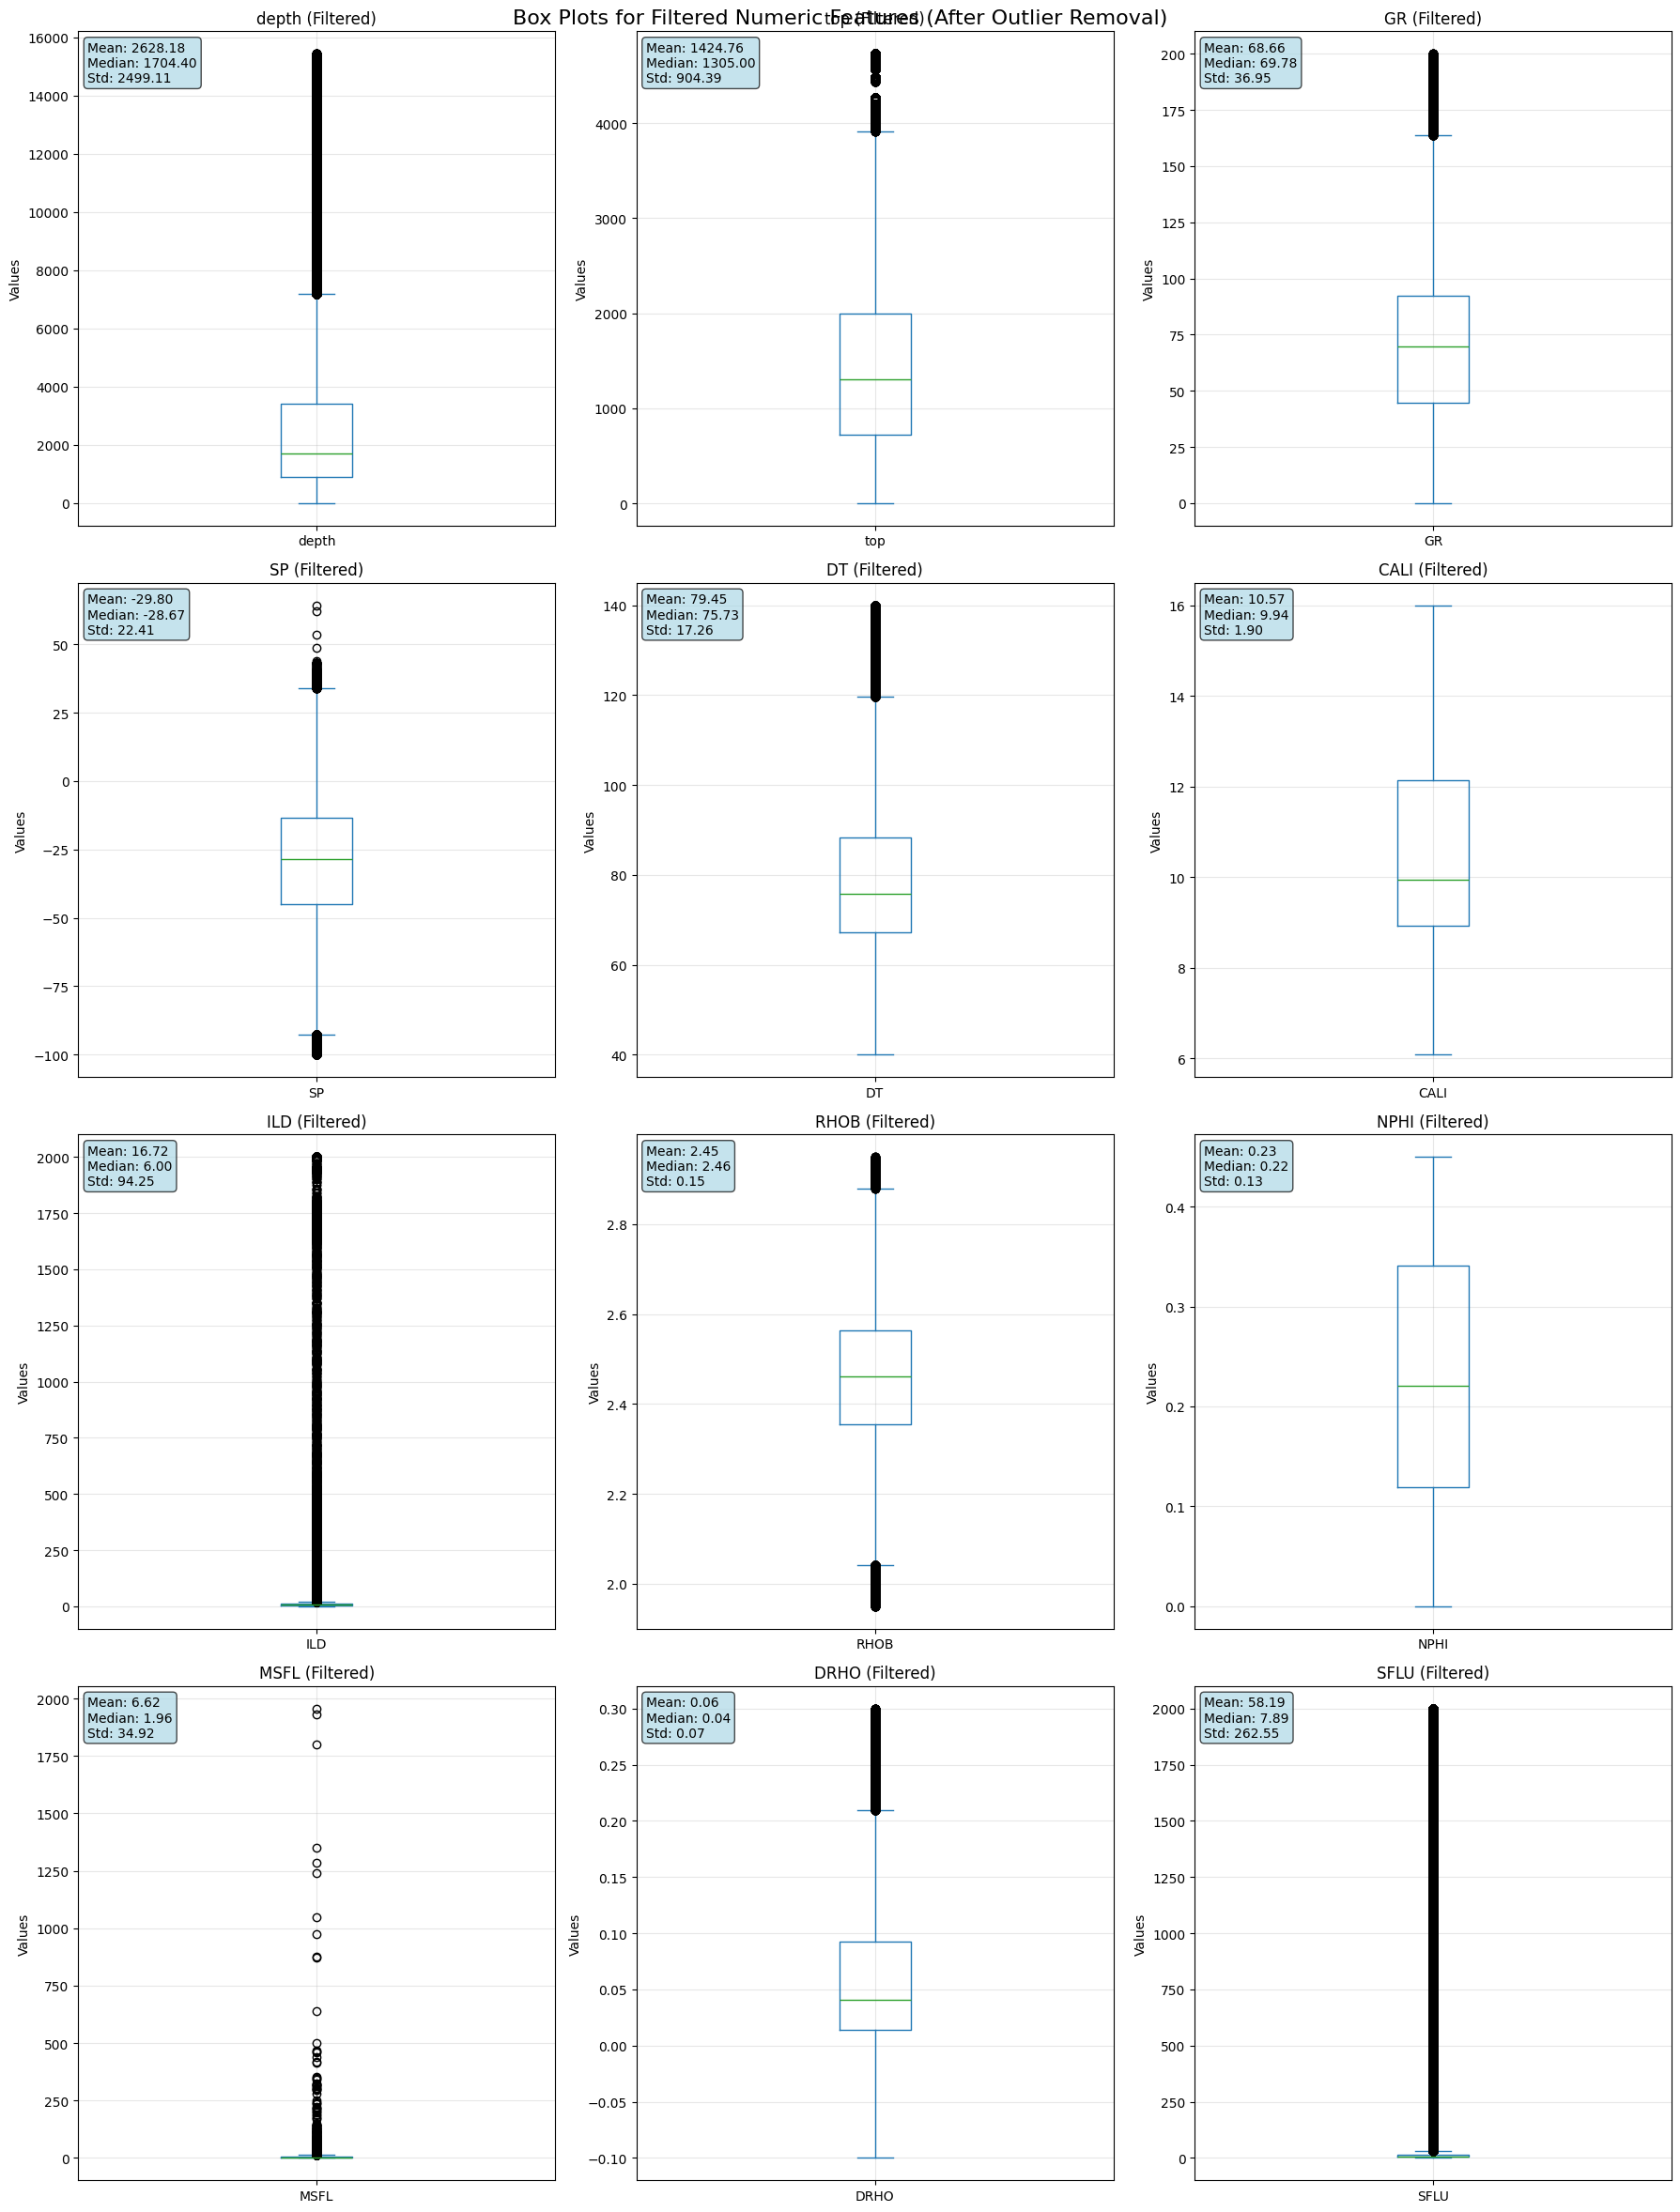

In [56]:
import matplotlib.pyplot as plt
# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = features_columns.copy()#[col for col in features_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 2) // 3  # 3 columns per row
fig, axes = plt.subplots(n_rows_clean, 3, figsize=(18, 6 * n_rows_clean))
fig.suptitle('Box Plots for Filtered Numeric Features (After Outlier Removal)', fontsize=16, y=0.98)

# Handle single subplot case
if n_cols_clean == 1:
    axes = [axes]
elif n_rows_clean == 1:
    axes = axes if n_cols_clean > 1 else [axes]
else:
    axes = axes.flatten()

# Create box plots for filtered data
for i, col in enumerate(filtered_numeric_columns_clean):
    ax = axes[i] if n_cols_clean > 1 else axes[0]
    
    # Create box plot
    df_features_filtered[col].plot(kind='box', ax=ax, title=f'{col} (Filtered)')
    ax.set_ylabel('Values')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {df_features_filtered[col].mean():.2f}\nMedian: {df_features_filtered[col].median():.2f}\nStd: {df_features_filtered[col].std():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

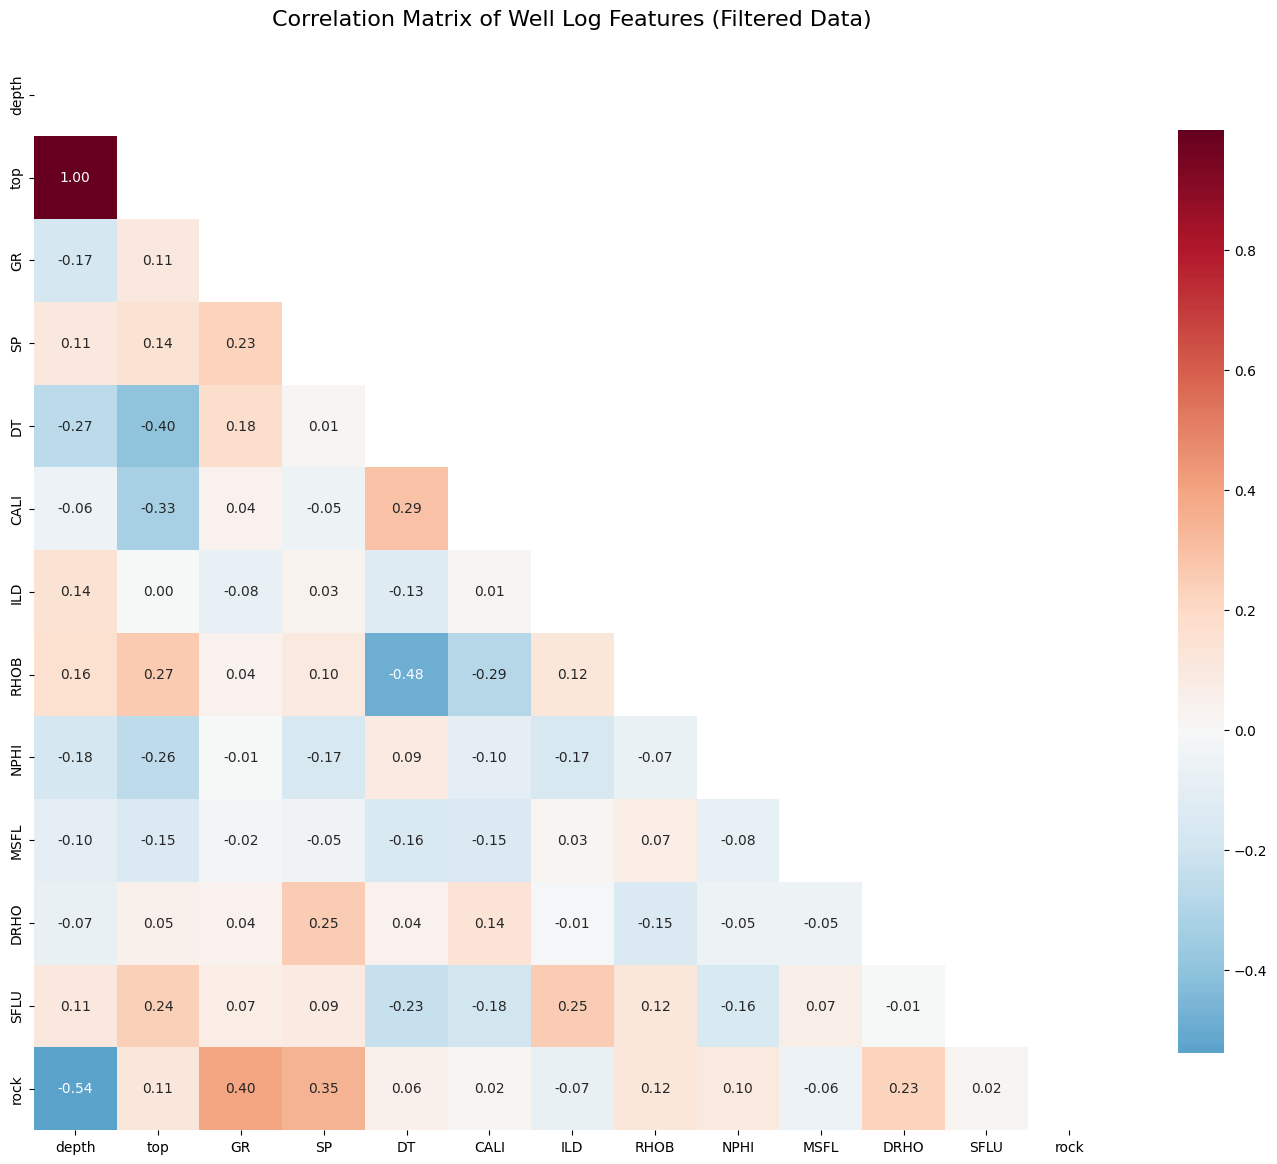


Strong Correlations (|r| > 0.7):

Normal Correlations (|r| > 0.4):

Weak Correlations (|r| > 0.1):
  Feature 1 Feature 2  Correlation
0     depth       top     0.999846

Normal Correlations (|r| > 0.4):
  Feature 1 Feature 2  Correlation
0     depth      rock    -0.538705
2        DT      RHOB    -0.483912
1       top        DT    -0.400910

Weak Correlations (|r| > 0.1):
   Feature 1 Feature 2  Correlation
17        GR      rock     0.398193
20        SP      rock     0.345724
9        top      CALI    -0.334062
21        DT      CALI     0.294146
25      CALI      RHOB    -0.285492
2      depth        DT    -0.267851
10       top      RHOB     0.266029
11       top      NPHI    -0.259710
31       ILD      SFLU     0.251779
19        SP      DRHO     0.248781
13       top      SFLU     0.239943
15        GR        SP     0.231564
36      DRHO      rock     0.228489
24        DT      SFLU    -0.226249
28      CALI      SFLU    -0.184845
5      depth      NPHI    -0.177389
16        GR

In [57]:
columns = filtered_numeric_columns_clean.copy()
columns.extend(["rock"])

df_features_cleaned = df_features_filtered.copy()
df_features_cleaned["rock"] = df_features_filtered["rock"].astype('category').cat.codes

# Create correlation matrix for numeric columns in the filtered dataset
correlation_matrix = df_features_cleaned[columns].corr()

# Create heatmap using matplotlib and seaborn
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Well Log Features (Filtered Data)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Print strong correlations (absolute value > 0.7)
print("\nStrong Correlations (|r| > 0.7):")
print("\nNormal Correlations (|r| > 0.4):")
print("\nWeak Correlations (|r| > 0.1):")
print("=" * 50)
strong_corr = []
normal_corr = []
weak_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.4:
            normal_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.1:
            weak_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
    print(strong_corr_df)
else:
    print("No strong correlations found (|r| > 0.7)")
    
if normal_corr:
    normal_corr_df = pd.DataFrame(normal_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nNormal Correlations (|r| > 0.4):")
    print(normal_corr_df)
else:
    print("No normal correlations found (|r| > 0.4)")
if weak_corr:
    weak_corr_df = pd.DataFrame(weak_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nWeak Correlations (|r| > 0.1):")
    print(weak_corr_df)
else:
    print("No weak correlations found (|r| > 0.1)")

In [58]:
# Add boolean columns indicating null values for each numeric column
for col in numeric_columns:
    df_features_filtered[f'{col}_is_null'] = df_features_filtered[col].isnull().astype(int)

# Display the updated dataframe with null indicator columns
print("Added null indicator columns:")
print(df_features_filtered.columns.tolist())
print("\nDataframe shape:", df_features_filtered.shape)
print("\nSample of null indicator columns:")
null_indicator_cols = [col for col in df_features_filtered.columns if col.endswith('_is_null')]
print(df_features_filtered[null_indicator_cols].head())

Added null indicator columns:
['well', 'depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL', 'DRHO', 'SFLU', 'top', 'bottom', 'rock', 'depth_is_null', 'GR_is_null', 'SP_is_null', 'DT_is_null', 'CALI_is_null', 'ILD_is_null', 'RHOB_is_null', 'NPHI_is_null', 'MSFL_is_null', 'DRHO_is_null', 'SFLU_is_null', 'top_is_null', 'bottom_is_null']

Dataframe shape: (1000000, 28)

Sample of null indicator columns:
   depth_is_null  GR_is_null  SP_is_null  DT_is_null  CALI_is_null  \
0              0           0           1           1             1   
1              0           0           1           1             1   
2              0           0           1           1             1   
3              0           0           1           1             1   
4              0           0           1           1             1   

   ILD_is_null  RHOB_is_null  NPHI_is_null  MSFL_is_null  DRHO_is_null  \
0            1             1             1             1             1   
1            1 

In [59]:
features_columns = [
        'depth',
        'depth_is_null',
        'top',
        'top_is_null',
        'GR', 
        'GR_is_null',
        'SP', 
        'SP_is_null',
        'DT', 
        'DT_is_null',
        'CALI', 
        'CALI_is_null',
        'ILD', 
        'ILD_is_null',
        'RHOB', 
        'RHOB_is_null',
        'NPHI', 
        'NPHI_is_null',
        'MSFL',
        'MSFL_is_null',
        'DRHO', 
        'DRHO_is_null',
        'SFLU',
        'SFLU_is_null']

Total unique wells: 63
Training wells: 50
Testing wells: 13

Training data shape: (711025, 24)
Testing data shape: (288975, 24)

Selected columns: ['depth', 'depth_is_null', 'top', 'top_is_null', 'GR', 'GR_is_null', 'SP', 'SP_is_null', 'DT', 'DT_is_null', 'CALI', 'CALI_is_null', 'ILD', 'ILD_is_null', 'RHOB', 'RHOB_is_null', 'NPHI', 'NPHI_is_null', 'MSFL', 'MSFL_is_null', 'DRHO', 'DRHO_is_null', 'SFLU', 'SFLU_is_null']


# Training

In [60]:
from sklearn.model_selection import train_test_split

# Get unique wells
unique_wells = df_features_filtered['well'].unique() if 'well' in df_features_filtered.columns else df_features['well'].unique()

# Split wells into train and test (80-20 split)
train_wells, test_wells = train_test_split(unique_wells, test_size=0.2, random_state=42)

# Create train and test datasets based on well splits
train_data = df_features_filtered[df_features_filtered['well'].isin(train_wells)][features_columns]
test_data = df_features_filtered[df_features_filtered['well'].isin(test_wells)][features_columns]

print(f"Total unique wells: {len(unique_wells)}")
print(f"Training wells: {len(train_wells)}")
print(f"Testing wells: {len(test_wells)}")
print(f"\nTraining data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")
print(f"\nSelected columns: {features_columns}")

Total unique wells: 63
Training wells: 50
Testing wells: 13

Training data shape: (711025, 24)
Testing data shape: (288975, 24)

Selected columns: ['depth', 'depth_is_null', 'top', 'top_is_null', 'GR', 'GR_is_null', 'SP', 'SP_is_null', 'DT', 'DT_is_null', 'CALI', 'CALI_is_null', 'ILD', 'ILD_is_null', 'RHOB', 'RHOB_is_null', 'NPHI', 'NPHI_is_null', 'MSFL', 'MSFL_is_null', 'DRHO', 'DRHO_is_null', 'SFLU', 'SFLU_is_null']


In [44]:
train_data

,depth,depth_is_null,top,top_is_null,GR,GR_is_null,SP,SP_is_null,DT,DT_is_null,...,RHOB,RHOB_is_null,NPHI,NPHI_is_null,MSFL,MSFL_is_null,DRHO,DRHO_is_null,SFLU,SFLU_is_null
12549,351.0,0,348.5,0,58.388992,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12550,351.2,0,348.5,0,58.075989,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12551,351.4,0,348.5,0,57.244995,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12552,351.6,0,348.5,0,56.727997,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12553,351.8,0,348.5,0,56.614990,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1788.2,0,1782.0,0,105.457748,0,-3.301666,0,74.474747,0,...,NaN,1,NaN,1,NaN,1,NaN,1,4.040940,0
999996,1788.4,0,1782.0,0,98.367188,0,-5.609985,0,69.902344,0,...,NaN,1,NaN,1,NaN,1,NaN,1,5.707031,0
999997,1788.6,0,1782.0,0,98.895508,0,-6.745575,0,69.823212,0,...,NaN,1,NaN,1,NaN,1,NaN,1,7.059439,0
999998,1788.8,0,1782.0,0,NaN,1,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1


In [ ]:

# Get target column from training and test data
train_target = df_features_filtered[df_features_filtered['well'].isin(train_wells)][target_column]
test_target = df_features_filtered[df_features_filtered['well'].isin(test_wells)][target_column]

train_mask = train_target.notna()
test_mask = test_target.notna()

print(f"Training target shape: {train_target.shape}")
print(f"Testing target shape: {test_target.shape}")
print(f"\nTraining target distribution:")
print(train_target.value_counts())
print(f"\nTesting target distribution:")
print(test_target.value_counts())

Training target shape: (711025,)
Testing target shape: (288975,)

Training target distribution:
rock
FOLHELHO        246447
ARENITO         209867
SILTITO          48341
ARGILITO         21579
CALCILUTITO      21150
AREIA             6607
ARGILA            5496
CALCARENITO       5209
CONGLOMERADO      4918
CALCARIO          4848
GRANITO           2797
ANIDRITA          1143
DOLOMITO          1083
BASALTO            322
MARGA              167
Name: count, dtype: int64

Testing target distribution:
rock
FOLHELHO        77432
ARENITO         68317
SILTITO         13971
ARGILITO         8867
CALCILUTITO      7621
CALCARENITO      1685
AREIA            1628
BASALTO           454
ARGILA            390
ANIDRITA          290
CALCARIO          243
MARGA              56
CONGLOMERADO       16
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Create masks for training and testing data
train_mask = train_target.notna()
test_mask = test_target.notna()

train_data = train_data[train_mask]
train_target = train_target[train_mask]
test_data = test_data[test_mask]
test_target = test_target[test_mask]

# Handle missing values by imputing with median for numeric features
imputer = SimpleImputer(strategy='median')
train_data_imputed = imputer.fit_transform(train_data)
test_data_imputed = imputer.transform(test_data)

# Train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    verbose=1,  # This will show progress during training
    warm_start=True,  # Allow incremental training to track progress
    bootstrap=False  # Disable bootstrap to avoid breaking the sequential nature of well logs
)

# Train the model
print("Training Random Forest model...")
rf_model.fit(train_data_imputed, train_target)

# Make predictions
train_predictions = rf_model.predict(train_data_imputed)
test_predictions = rf_model.predict(test_data_imputed)

# Calculate accuracies
train_accuracy = accuracy_score(train_target, train_predictions)
test_accuracy = accuracy_score(test_target, test_predictions)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Show classification report for test set
print("\nClassification Report (Test Set):")
print(classification_report(test_target, test_predictions))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Training Random Forest model...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.3min
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  5.2min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   10.4s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   19.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.3s finished



Training Accuracy: 0.9988
Testing Accuracy: 0.5340

Classification Report (Test Set):


c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    ANIDRITA       0.01      0.00      0.00       290
       AREIA       0.30      0.36      0.33      1628
     ARENITO       0.56      0.59      0.58     68317
      ARGILA       0.10      0.21      0.13       390
    ARGILITO       0.34      0.16      0.22      8867
     BASALTO       0.71      0.20      0.31       454
 CALCARENITO       0.24      0.07      0.11      1685
    CALCARIO       0.00      0.00      0.00       243
 CALCILUTITO       0.12      0.02      0.04      7621
CONGLOMERADO       0.00      0.00      0.00        16
    DOLOMITO       0.00      0.00      0.00         0
    FOLHELHO       0.56      0.68      0.61     77432
       MARGA       0.00      0.00      0.00        56
     SILTITO       0.17      0.05      0.08     13971

    accuracy                           0.53    180970
   macro avg       0.22      0.17      0.17    180970
weighted avg       0.49      0.53      0.50    180970


Top 10 Most Important Fe

# TRAIN THE MODELS

## Preparing the dataset

In [27]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [28]:
database_path = Path("../") / "slide" / "database" / "features.db"
conn = sqlite3.connect(database_path)
query = "SELECT * FROM Features limit 1000000;"
df_features = pd.read_sql_query(query, conn)
df_features

,well,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom,rock
0,1BT2AM,270.0,63.279785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
1,1BT2AM,270.2,62.580566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
2,1BT2AM,270.4,64.454590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
3,1BT2AM,270.6,65.624268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
4,1BT2AM,270.8,64.920898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3PIR7AL,1788.2,105.457748,-3.301666,74.474747,-999.25,4.499398,-999.25,-999.25,NaN,-999.25,4.040940,1782.0,1790.0,FOLHELHO
999996,3PIR7AL,1788.4,98.367188,-5.609985,69.902344,-999.25,4.501740,-999.25,-999.25,NaN,-999.25,5.707031,1782.0,1790.0,FOLHELHO
999997,3PIR7AL,1788.6,98.895508,-6.745575,69.823212,-999.25,4.713235,-999.25,-999.25,NaN,-999.25,7.059439,1782.0,1790.0,FOLHELHO
999998,3PIR7AL,1788.8,-999.250000,NaN,NaN,-999.25,NaN,-999.25,-999.25,NaN,-999.25,NaN,1782.0,1790.0,FOLHELHO


In [29]:
target_column = 'rock'
features_columns = [
        'depth',
        'top',
        'GR', 
        'SP', 
        'DT', 
        'CALI', 
        'ILD', 
        'RHOB', 
        'NPHI', 
        'MSFL',
        'DRHO', 
        'SFLU']
valid_rocks = [
    'FOLHELHO', 'ARENITO', 'SILTITO', 'CALCILUTITO', 'AREIA', 'CALCARENITO',
    'ARGILA', 'CALCARIO', 'CONGLOMERADO', 'ARGILITO', 'ANIDRITA', 'MARGA',
    'GRANITO', 'BASALTO', 'DOLOMITO'
]

for col in features_columns:
    if col == "GR":
        df_features[col] = np.where((df_features[col] >= 0) & (df_features[col] <= 200), df_features[col], np.nan)
    elif col == "SP":
        df_features[col] = np.where((df_features[col] >= -100) & (df_features[col] <= 100), df_features[col], np.nan)
    elif col == "DT":
        df_features[col] = np.where((df_features[col] >= 40) & (df_features[col] <= 140), df_features[col], np.nan)
    elif col == "CALI":
        df_features[col] = np.where((df_features[col] >= 6) & (df_features[col] <= 16), df_features[col], np.nan)
    elif col == "ILD":
        df_features[col] = np.where((df_features[col] >= 0.2) & (df_features[col] <= 2000), df_features[col], np.nan)
    elif col == "RHOB":
        df_features[col] = np.where((df_features[col] >= 1.95) & (df_features[col] <= 2.95), df_features[col], np.nan)
    elif col == "NPHI":
        df_features[col] = np.where((df_features[col] >= 0) & (df_features[col] <= 0.45), df_features[col], np.nan)
    elif col == "MSFL":
        df_features[col] = np.where((df_features[col] >= 0.2) & (df_features[col] <= 2000), df_features[col], np.nan)
    elif col == "DRHO":
        df_features[col] = np.where((df_features[col] >= -0.1) & (df_features[col] <= 0.3), df_features[col], np.nan)
    elif col == "SFLU":
        df_features[col] = np.where((df_features[col] >= 0.2) & (df_features[col] <= 2000), df_features[col], np.nan)

# Filter rows based on valid rock types
df_features["rock"] = np.where(df_features['rock'].isin(valid_rocks), df_features["rock"], np.nan)

In [30]:
def add_sequential_features(df: pd.DataFrame, features_columns: list) -> pd.DataFrame:
    """Add lagged features to capture sequential dependencies"""
    df = df.sort_values(['well', 'depth'])  # Ensure sorted by well and depth
    
    # Add lagged features (previous depth values)
    for col in features_columns:
        # Previous value (lag 1)
        df[f'{col}_lag1'] = df.groupby('well')[col].shift(1)
        # Previous 2 values (lag 2)
        df[f'{col}_lag2'] = df.groupby('well')[col].shift(2)
        
        # Rolling statistics (window of 3)
        df[f'{col}_rolling_mean'] = df.groupby('well')[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).mean()
        )
        df[f'{col}_rolling_std'] = df.groupby('well')[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).std()
        )
        
        # Rate of change
        df[f'{col}_diff'] = df.groupby('well')[col].diff()
    
    return df

In [31]:
df_features = add_sequential_features(df_features, features_columns)

# Add boolean columns indicating null values for each numeric column
for col in features_columns:
    df_features[f'{col}_is_null'] = df_features[col].isnull().astype(int)
df_features

,well,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,...,GR_is_null,SP_is_null,DT_is_null,CALI_is_null,ILD_is_null,RHOB_is_null,NPHI_is_null,MSFL_is_null,DRHO_is_null,SFLU_is_null
118489,1BT1AM,260.0,64.528076,-28.786743,NaN,12.369999,NaN,NaN,NaN,NaN,...,0,0,1,0,1,1,1,1,1,1
118490,1BT1AM,260.2,62.335938,-33.783554,NaN,12.250000,NaN,NaN,NaN,NaN,...,0,0,1,0,1,1,1,1,1,1
118491,1BT1AM,260.4,58.904785,-38.780380,NaN,12.109999,NaN,NaN,NaN,NaN,...,0,0,1,0,1,1,1,1,1,1
118492,1BT1AM,260.6,58.125000,-43.777191,NaN,12.000000,NaN,NaN,NaN,NaN,...,0,0,1,0,1,1,1,1,1,1
118493,1BT1AM,260.8,58.125732,-48.774002,NaN,11.889999,NaN,NaN,NaN,NaN,...,0,0,1,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173742,6TM54AL,4237.0,NaN,-1.135080,NaN,NaN,1.371407,NaN,NaN,NaN,...,1,0,1,1,0,1,1,1,1,0
173743,6TM54AL,4237.2,NaN,5.229767,NaN,NaN,2.043795,NaN,NaN,NaN,...,1,0,1,1,0,1,1,1,1,0
173744,6TM54AL,4237.4,NaN,11.953863,NaN,NaN,3.363131,NaN,NaN,NaN,...,1,0,1,1,0,1,1,1,1,0
173745,6TM54AL,4237.6,NaN,17.583908,NaN,NaN,6.209961,NaN,NaN,NaN,...,1,0,1,1,0,1,1,1,1,0


In [32]:
# Get unique wells
unique_wells = df_features['well'].unique() if 'well' in df_features.columns else df_features['well'].unique()

# Split wells into train and test (80-20 split)
train_wells, test_wells = train_test_split(unique_wells, test_size=0.2, random_state=42)

# Create train and test datasets based on well splits
train_data = df_features[df_features['well'].isin(train_wells)]
test_data = df_features[df_features['well'].isin(test_wells)]

train_target = train_data[target_column]
test_target = test_data[target_column]
sequential_features = []
for col in features_columns:
    sequential_features.extend([
        f'{col}_lag1', f'{col}_lag2', 
        f'{col}_rolling_mean', f'{col}_rolling_std',
        f'{col}_diff'
    ])

feature_cols = features_columns + [f'{col}_is_null' for col in features_columns] + sequential_features
train_data = train_data[feature_cols]
test_data = test_data[feature_cols]
                

In [33]:
print(train_data.head())
print(train_target.head())

   depth    top         GR  SP  DT  CALI  ILD  RHOB  NPHI  MSFL  ...  \
0  270.0  204.0  63.279785 NaN NaN   NaN  NaN   NaN   NaN   NaN  ...   
1  270.2  204.0  62.580566 NaN NaN   NaN  NaN   NaN   NaN   NaN  ...   
2  270.4  204.0  64.454590 NaN NaN   NaN  NaN   NaN   NaN   NaN  ...   
3  270.6  204.0  65.624268 NaN NaN   NaN  NaN   NaN   NaN   NaN  ...   
4  270.8  204.0  64.920898 NaN NaN   NaN  NaN   NaN   NaN   NaN  ...   

   DRHO_lag1  DRHO_lag2  DRHO_rolling_mean  DRHO_rolling_std  DRHO_diff  \
0        NaN        NaN                NaN               NaN        NaN   
1        NaN        NaN                NaN               NaN        NaN   
2        NaN        NaN                NaN               NaN        NaN   
3        NaN        NaN                NaN               NaN        NaN   
4        NaN        NaN                NaN               NaN        NaN   

   SFLU_lag1  SFLU_lag2  SFLU_rolling_mean  SFLU_rolling_std  SFLU_diff  
0        NaN        NaN                NaN

## Training the models

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Remove rows with missing target values
train_mask = train_target.notna()
test_mask = test_target.notna()

train_data_clean = train_data[train_mask]
train_target_clean = train_target[train_mask]
test_data_clean = test_data[test_mask]
test_target_clean = test_target[test_mask]

param_grid = {
    'n_estimators': [50, 100, 200, 300],           # Number of trees
    'max_depth': [15, 20, 25, None],           # Tree depth (None = unlimited)
    'min_samples_split': [10, 20, 50],         # Min samples to split a node
    'min_samples_leaf': [5, 10, 20],           # Min samples in leaf nodes
    'max_features': ['sqrt', 'log2', 0.5],     # Features considered for split
    'max_samples': [0.7, 0.8, None],           # Bootstrap sample size (None = use all)
    'class_weight': ['balanced', None]         # Handle class imbalance
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        bootstrap=True,      # Enable bootstrap sampling
        oob_score=True,      # Out-of-bag score for validation
        ),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(train_data_clean, train_target_clean)
model = grid_search.best_estimator_

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


accuracy = model.score(test_data_clean, test_target_clean)

predictions = model.predict(test_data_clean)
results = {
    "accuracy": accuracy,
    "oob_score": model.oob_score_ if hasattr(model, 'oob_score_') else None,
    "classification_report": classification_report(test_target_clean, predictions),
    "confusion_matrix": confusion_matrix(test_target_clean, predictions)
}
print(f"\nTest Accuracy: {results['accuracy']:.4f}")

Training Random Forest model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.8min finished
[Parallel(n_jobs=28)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=28)]: Done 100 out of 100 | elapsed:    2.1s finished
[Parallel(n_jobs=28)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=28)]: Done 100 out of 100 | elapsed:    0.6s finished



Training Accuracy: 0.9995
Testing Accuracy: 0.5793

Classification Report:


c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    ANIDRITA       0.00      0.00      0.00       317
       AREIA       0.74      0.30      0.42      1541
     ARENITO       0.60      0.67      0.63     64133
      ARGILA       0.09      0.07      0.08       662
    ARGILITO       0.01      0.00      0.00      6309
     BASALTO       0.00      0.00      0.00        98
 CALCARENITO       0.53      0.03      0.05      1775
    CALCARIO       0.00      0.00      0.00      1290
 CALCILUTITO       0.13      0.02      0.04      6426
CONGLOMERADO       0.00      0.00      0.00       428
    DOLOMITO       0.00      0.00      0.00         0
    FOLHELHO       0.60      0.73      0.66     80132
     GRANITO       0.00      0.00      0.00         6
       MARGA       0.00      0.00      0.00        89
     SILTITO       0.12      0.02      0.03     13608

    accuracy                           0.58    176814
   macro avg       0.19      0.12      0.13    176814
weighted avg       0.51   

c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Plot confusion matrix
cm = confusion_matrix(test_target_clean, test_predictions_decoded, labels=label_encoder.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('XGBoost Confusion Matrix (Test Set)', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
# After training, analyze which sequential features matter:
feature_importance = pd.DataFrame({
    'feature': train_data_clean.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Check if lag/rolling features are important
print(feature_importance[feature_importance['feature'].str.contains('lag|rolling|diff')])

               feature  importance
36     GR_rolling_mean    0.043181
31    top_rolling_mean    0.042768
29            top_lag1    0.039905
25          depth_lag2    0.038058
26  depth_rolling_mean    0.037875
30            top_lag2    0.037689
24          depth_lag1    0.036482
35             GR_lag2    0.036178
41     SP_rolling_mean    0.035879
34             GR_lag1    0.033767
40             SP_lag2    0.028842
39             SP_lag1    0.027497
56    ILD_rolling_mean    0.017780
37      GR_rolling_std    0.016942
42      SP_rolling_std    0.016101
54            ILD_lag1    0.015398
55            ILD_lag2    0.014842
51   CALI_rolling_mean    0.014753
38             GR_diff    0.013564
61   RHOB_rolling_mean    0.013445
57     ILD_rolling_std    0.013178
43             SP_diff    0.013170
50           CALI_lag2    0.011738
52    CALI_rolling_std    0.011469
49           CALI_lag1    0.011459
76   DRHO_rolling_mean    0.010524
46     DT_rolling_mean    0.009840
58            ILD_di

Classes: ['ANIDRITA' 'AREIA' 'ARENITO' 'ARGILA' 'ARGILITO' 'BASALTO' 'CALCARENITO'
 'CALCARIO' 'CALCILUTITO' 'CONGLOMERADO' 'DOLOMITO' 'FOLHELHO' 'GRANITO'
 'MARGA' 'SILTITO']
Number of classes: 15

Training XGBoost model...
[0]	validation_0-mlogloss:2.19007	validation_1-mlogloss:2.24663
[50]	validation_0-mlogloss:0.69049	validation_1-mlogloss:1.19187
[100]	validation_0-mlogloss:0.59999	validation_1-mlogloss:1.23808
[150]	validation_0-mlogloss:0.55133	validation_1-mlogloss:1.29254
[199]	validation_0-mlogloss:0.51262	validation_1-mlogloss:1.32777

XGBoost Results:
Training Accuracy: 0.8031
Testing Accuracy: 0.6035
Overfitting Gap: 0.1996

Classification Report (Test Set):


c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    ANIDRITA       0.00      0.00      0.00       317
       AREIA       0.68      0.28      0.40      1541
     ARENITO       0.63      0.70      0.66     64133
      ARGILA       0.13      0.12      0.13       662
    ARGILITO       0.00      0.00      0.00      6309
     BASALTO       0.00      0.00      0.00        98
 CALCARENITO       0.96      0.08      0.15      1775
    CALCARIO       0.00      0.00      0.00      1290
 CALCILUTITO       0.29      0.08      0.13      6426
CONGLOMERADO       0.09      0.18      0.11       428
    DOLOMITO       0.00      0.00      0.00         0
    FOLHELHO       0.61      0.75      0.68     80132
     GRANITO       0.00      0.00      0.00         6
       MARGA       0.00      0.00      0.00        89
     SILTITO       0.15      0.02      0.03     13608

    accuracy                           0.60    176814
   macro avg       0.24      0.15      0.15    176814
weighted avg       0.54   

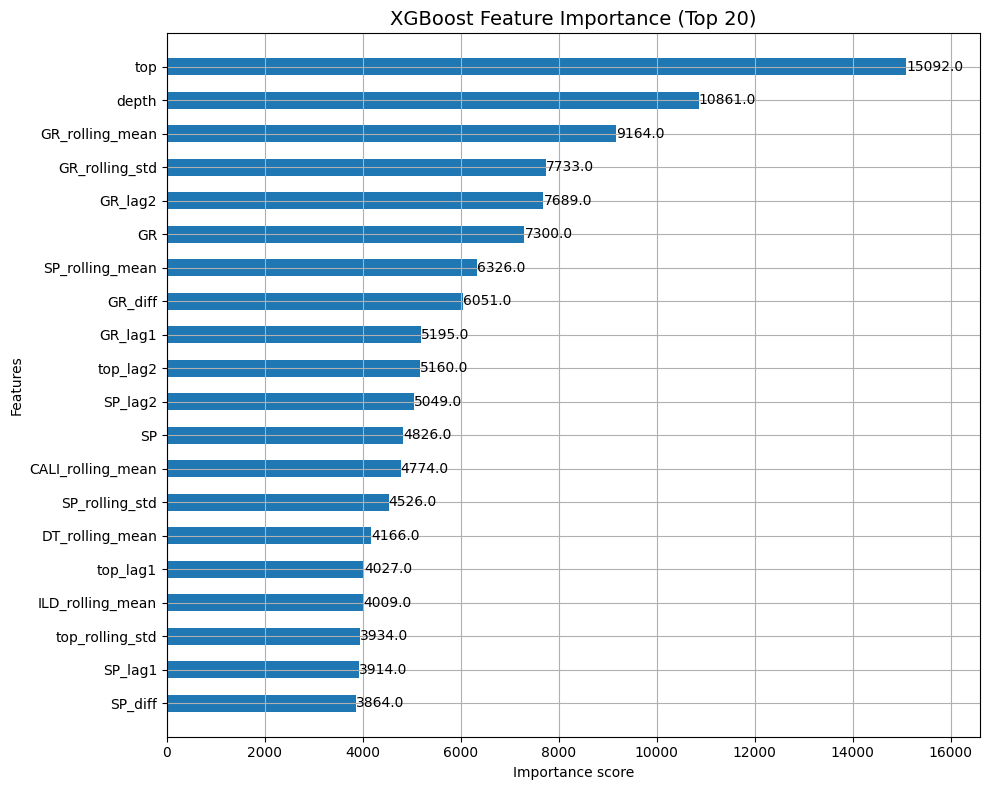

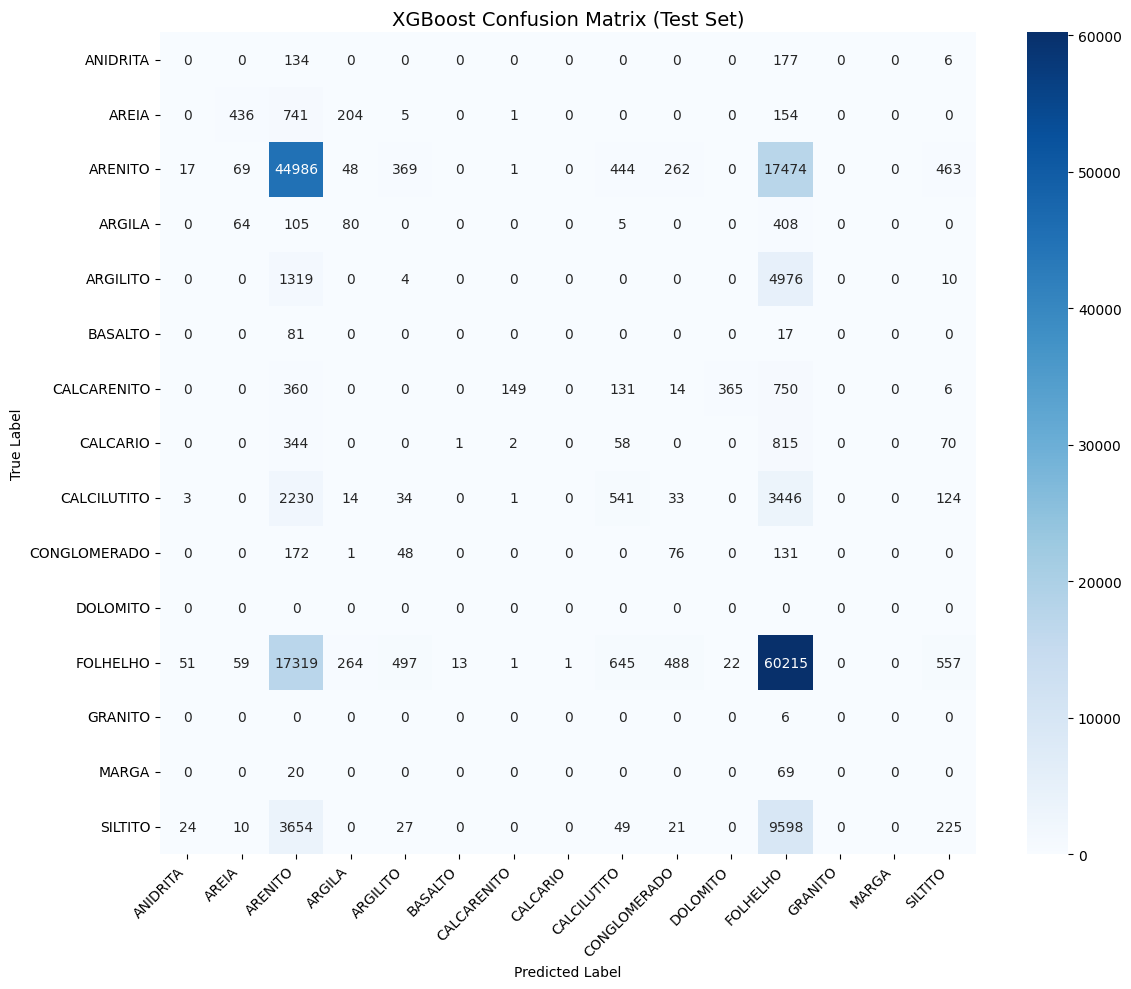


Sequential Features Importance:
               feature  importance
41     SP_rolling_mean    0.050367
26  depth_rolling_mean    0.036095
56    ILD_rolling_mean    0.035773
71   MSFL_rolling_mean    0.033179
36     GR_rolling_mean    0.028959
61   RHOB_rolling_mean    0.027002
24          depth_lag1    0.022505
29            top_lag1    0.022410
31    top_rolling_mean    0.021799
28          depth_diff    0.021757
57     ILD_rolling_std    0.020506
27   depth_rolling_std    0.019922
25          depth_lag2    0.019609
51   CALI_rolling_mean    0.017567
81   SFLU_rolling_mean    0.017257
30            top_lag2    0.016310
35             GR_lag2    0.014980
42      SP_rolling_std    0.014683
73           MSFL_diff    0.014431
34             GR_lag1    0.014217


In [39]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Remove rows with missing target values (reuse from RF)
train_mask = train_target.notna()
test_mask = test_target.notna()

train_data_clean = train_data[train_mask]
train_target_clean = train_target[train_mask]
test_data_clean = test_data[test_mask]
test_target_clean = test_target[test_mask]

# Encode target labels (XGBoost requires numeric labels)
label_encoder = LabelEncoder()
train_target_encoded = label_encoder.fit_transform(train_target_clean)
test_target_encoded = label_encoder.transform(test_target_clean)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

# Train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',  # Faster for large datasets
    enable_categorical=False,
    missing=np.nan,  # Handle missing values natively
    eval_metric='mlogloss',  # Multi-class log loss
    verbosity=1
)

print("\nTraining XGBoost model...")
xgb_model.fit(
    train_data_clean, 
    train_target_encoded,
    eval_set=[(train_data_clean, train_target_encoded), 
              (test_data_clean, test_target_encoded)],
    verbose=50  # Print every 50 iterations
)

# Predictions
train_predictions_xgb = xgb_model.predict(train_data_clean)
test_predictions_xgb = xgb_model.predict(test_data_clean)

# Decode predictions back to original labels
train_predictions_decoded = label_encoder.inverse_transform(train_predictions_xgb)
test_predictions_decoded = label_encoder.inverse_transform(test_predictions_xgb)

# Evaluation
train_accuracy_xgb = accuracy_score(train_target_clean, train_predictions_decoded)
test_accuracy_xgb = accuracy_score(test_target_clean, test_predictions_decoded)

print(f"\n{'='*60}")
print(f"XGBoost Results:")
print(f"{'='*60}")
print(f"Training Accuracy: {train_accuracy_xgb:.4f}")
print(f"Testing Accuracy: {test_accuracy_xgb:.4f}")
print(f"Overfitting Gap: {train_accuracy_xgb - test_accuracy_xgb:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(test_target_clean, test_predictions_decoded))

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': train_data_clean.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(15))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=20, height=0.5, ax=ax)
plt.title('XGBoost Feature Importance (Top 20)', fontsize=14)
plt.tight_layout()
plt.show()

# Plot confusion matrix
cm = confusion_matrix(test_target_clean, test_predictions_decoded, labels=label_encoder.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('XGBoost Confusion Matrix (Test Set)', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Check sequential features importance
print("\nSequential Features Importance:")
seq_features = feature_importance_xgb[feature_importance_xgb['feature'].str.contains('lag|rolling|diff')]
print(seq_features.head(20))